# Prosjekt 2

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import tqdm
from numba import njit


## Oppgave 1

### 1a)


Partiellderiverer 

$$
\phi(x,t) = \frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y) e^{-\frac{(x-y)^2}{4Dt}}  dy
\tag{1}
$$ 

med hensyn på t og dobbelt på x.
<br>
<br>
<br>
<br>
<br>


$$
\frac{\partial \phi}{\partial t} = 
- \frac{1}{2}\frac{4\pi D}{\sqrt{(4\pi D t)^3}} \int_{-\infty}^{\infty} h(y) e^{-\frac{(x-y)^2}{4Dt}}  dy 
+ \frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y) \frac{(x-y)^2}{4Dt^2} e^{-\frac{(x-y)^2}{4Dt}} dy
\tag{2}
$$

som kan forenkles til


$$
\frac{\partial \phi}{\partial t} = \frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y)  e^{-\frac{(x-y)^2}{4Dt}} \frac{(x-y)^2-2Dt}{4Dt^2} dy
\tag{3}
$$
<br>
<br>
<br>
<br>
<br>

Tar så den dobbelderiverte av $\phi$ mhp x

$$
\frac{\partial \phi}{\partial x} = \frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y) 
(-\frac{2 (x-y)}{4Dt}) e^{-\frac{(x-y)^2}{4Dt}}
\tag{4}
$$

$$
\frac{\partial^2 f}{\partial x^2} = \frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y) e^{-\frac{(x-y)^2}{4Dt}} \left(-\frac{2(x-y)}{4Dt}\right)^2 dy + \frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y) e^{-\frac{(x-y)^2}{4Dt}} \left(-\frac{2}{4Dt}\right)  dy
\tag{5}
$$

som kan forenkles til 

$$
\frac{\partial^2 f}{\partial x^2} = \frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y) e^{-\frac{(x-y)^2}{4Dt}} \left(\frac{(x-y)^2-2 D t}{4D^2 t^2}\right) dy
\tag{6}
$$
<br>
<br>
<br>
<br>
<br>


Setter man (3) og (6) inn i diffusjonslikningen (7) ser man at det er en løsning.
$$
\frac{\partial \phi}{\partial t} = D \frac{\partial^2 \phi}{\partial x^2}
\tag{7}
$$
<br>
<br>


$$
\frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y) \ e^{-\frac{(x-y)^2}{4Dt}} \frac{(x-y)^2-2Dt}{4Dt^2} dy = 
 D\frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} h(y) e^{-\frac{(x-y)^2}{4Dt}} \left(\frac{(x-y)^2-2 D t}{4D^2 t^2}\right)
 \tag{8}
 $$

 Dette kunne også ha blitt løst med kompleks analyse da uttrykket er en konvolusjon, men åpenbaringen kom for sent.

Fra (1) gjenkjennes 
$$
\frac{1}{\sqrt{4\pi D t}} \int_{-\infty}^{\infty} e^{-\frac{(x-y)^2}{4Dt}} dy
$$

som en normalfordeling med varians $\sigma ^2 = 2Dt$. Det er kjent at ved å ta grenseverdien til normalfordelingen til $0^+$ vil man få Diracs deltafunksjon. Videre blir da

$$
\phi(x,t) = \int_{-\infty}^{\infty} \delta (x-y)h(y) dy = h(x)
$$
Da $\phi$ representerer partikkelfordelingen vil h(y) er altså startposisjonen til partikklene


### 1b)



Fra oppgaveteksten har vi
$$
p^- = k P(x-1) \qquad   p^0 = k P(x)  \qquad   p^+ = k P(x+1)
$$
<br>
<br>
Som vi vet tilsammen blir

$$
p^- + p^0 + p^+ = k P(x-1) +k P(x) + k P(x+1) = 1
\tag{9}
$$
og får
$$
k = \frac{1}{P(x-1) + P(x) + P(x+1)}
$$

dermed er 


$$
p = k P(x) = \frac{e^{\beta V(x)}}{e^{-\beta V[x_0-1]} + e^{-\beta V[x_0]} + e^{-\beta V[x_0 + 1]}}
$$

<br>
<br>
<br>


Dette gir 

$$
p^+ = k P(x_0 + 1) = \frac{e^{-\beta V[x_0 + 1]}}{e^{-\beta V[x_0-1]} + e^{-\beta V[x_0]} + e^{-\beta V[x_0 + 1]}} = \frac{1}{e^{-\beta(V[x_0-1]-V[x_0+1])} + e^{-\beta(V[x_0]-V[x_0+1])} + 1}
$$
$$
p^0 = k P(x_0) = \frac{e^{-\beta V[x_0]}}{e^{-\beta V[x_0-1]} + e^{-\beta V[x_0]} + e^{-\beta V[x_0 + 1]}} = \frac{1}{e^{-\beta(V[x_0-1]-V[x_0])} + 1 + e^{-\beta(V[x_0 + 1]-V[x_0])}}
$$
$$
p^- = k P(x_0 - 1) = \frac{e^{-\beta V[x_0 - 1]}}{e^{-\beta V[x_0-1]} + e^{-\beta V[x_0]} + e^{-\beta V[x_0+ 1]}} 
= \frac{1}{1 + e^{-\beta(V[x_0]-V[x_0-1])} + e^{-\beta(V[x_0 + 1]-V[x_0 - 1 ])}}
$$


### 1c)



Da det gjelder for uansett x, og vi bare har tre punkter vil $ | V[x+1] - V[x-1] | $ være lik en annen $| V[x + 1] - V[x] |$ og dermed ved $ k_B T ≫ |V (x + 1) − V (x)| $ blir

$$
p^+ \approx p^0 \approx p^- \approx \frac{1}{1+e^0+e^0} = \frac{1}{3}
$$

For $ k_B T << |V (x + 1) − V (x)| $ er det litt mer komplisert, men la oss si at $ V[x_0]-1  > V[x_0]  > V[x_0]+1 $

Da er 
$$
p^+ = \frac{1}{e^{-\beta(V[x_0-1]-V[x_0+1])*} + e^{-\beta(V[x_0]-V[x_0+1])*} + 1}
$$
$$
p^0 = \frac{1}{e^{-\beta(V[x_0-1]-V[x_0])**} + 1 + e^{-\beta(V[x_0 + 1]-V[x_0])**}}
$$
$$
p^- = \frac{1}{1 + e^{-\beta(V[x_0]-V[x_0-1])**} + e^{-\beta(V[x_0 + 1]-V[x_0 - 1 ])**}}
$$

potensene blir negative for $p^+$ (merket med *) og leddene med e vil gå mot 0 ved $ k_B T << |V (x + 1) − V (x)| $. Og motsatt vil de bli positiv for $p^0$ og $p^-$ (merket med **) og e-leddene blir større, dermed blir $p^0$ og $p^-$ mindre. Dette gir
$$ 
p^+ \approx 1  \\ p^0 \approx 0  \\ p^- \approx 0
$$
Sannsynlighet blir altså tilnærmet 100% mot potensialet som er minst, altså $p^+$. Dette finner man også hvis man setter $ V[x_0]-1 $ eller $ V[x_0] $ som minst potensialet og hhv. $p^-$ og $p^0$ blir tilnærmet 100%.

## Oppgave 2

### 2a)

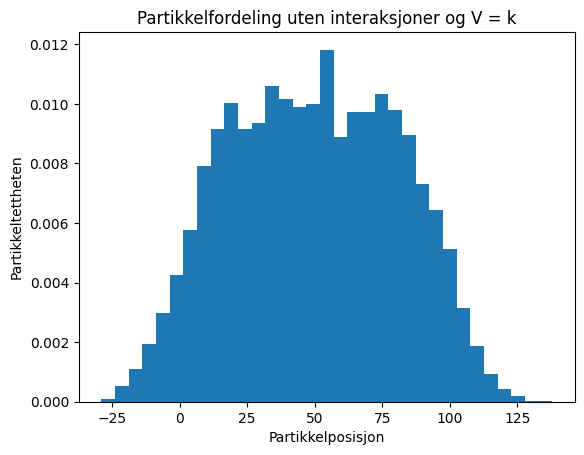

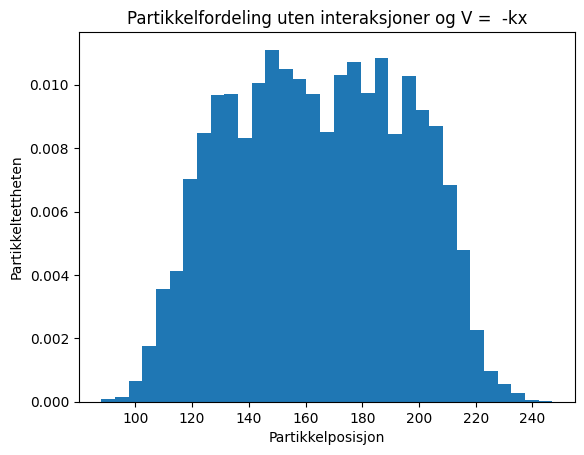

In [ ]:
#Definerer de ulike stegsannsynligheten fra beta og de ulike potensialen


def p_plus(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 - 1) - V(x_0 + 1))) + np.exp(-beta*(V(x_0) - V(x_0 + 1)))
    return 1/denonimator

def p_zero(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 - 1) - V(x_0))) + np.exp(-beta*(V(x_0 + 1) - V(x_0)))
    return 1/denonimator

def p_minus(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 + 1) - V(x_0 - 1))) + np.exp(-beta*(V(x_0) - V(x_0 - 1)))
    return 1/denonimator


#Definerer potensialene
def V_1(x):
    return k

def V_2(x):
    return - k * x

#Lager en klasse for virrevandring
class random_walk():
    #setter konstantene
    def __init__(self, beta_k_ratio : int, V): 
        k_b = sp.constants.Boltzmann
        self.n_particles = 100
        self.n_walks = 200
        self.V = V
        T = 273.15 + 37
        self.beta = (T * k_b)**-1
        self.k = beta_k_ratio * (T * k_b)
        global k
        k = self.k
        self.beta_k_ratio = beta_k_ratio
        self.oppg_a_vals = list()
        self.oppg_b_vals = list()

    #Bestemmer hvilke partikler som skal gå til venste og høyre i et steg
    def gen_walk_masks(self, particles):
        uniform_dist = np.random.uniform(0, 1, self.n_particles)
        x_0 = particles
        go_left = uniform_dist <= p_minus(x_0, self.beta, self.V)
        go_right = uniform_dist >= 1-p_plus(x_0, self.beta, self.V)
        return go_left, go_right

    #Setter partikklene til å gå i gitt retning, uten at de interagerer
    def oppg_a_step(self):
        particles = np.arange(0, self.n_particles, 1)
        for j in range(self.n_walks):
            go_left, go_right = self.gen_walk_masks(particles)
            particles[go_left] -= 1
            particles[go_right] += 1
        self.oppg_a_vals.append(particles)
    
    #Setter partikklene til å gå i gitt retning, med at de skjekker om plassen de går er tatt
    #De interagerer altså
    def oppg_b_step(self):
        particles = np.arange(0, self.n_particles, 1)
        for j in range(self.n_walks):
            go_left, go_right = self.gen_walk_masks(particles)
            movement_order = np.random.permutation(np.arange(0,self.n_particles))
            for idx in movement_order:
                if go_left[idx] == True:
                    if np.any(particles[idx] -1 == particles):
                        continue
                    else:
                        particles[idx] -= 1
                if go_right[idx] == True:
                    if np.any(particles[idx] + 1 == particles):
                        continue
                    else:
                        particles[idx] += 1
        self.oppg_b_vals.append(particles)


#Kjører simulasjonen
def oppg2_a():
    #Lager 2 instanser med virrevandring, en med hvert potensial.
    #Lar så gå uten interaksjon
    n_steps = 100

    walker_V1 = random_walk(beta_k_ratio=1, V=V_1)
    walker_V2 = random_walk(beta_k_ratio=1, V=V_2)

    for j in range(n_steps):
        walker_V1.oppg_a_step()
        
        walker_V2.oppg_a_step()
        


    verdier1 = np.array(walker_V1.oppg_a_vals).flatten()
    plt.hist(verdier1, density=True, bins=walker_V1.n_particles//3)
    plt.xlabel(f'Partikkelposisjon')
    plt.ylabel(f'Partikkeltettheten')
    plt.title(f'Partikkelfordeling uten interaksjoner og V = k')
    plt.show()

    verdier2 = np.array(walker_V2.oppg_a_vals).flatten()
    plt.hist(verdier2, density=True, bins=walker_V2.n_particles//3)
    plt.xlabel(f'Partikkelposisjon')
    plt.ylabel(f'Partikkeltettheten')
    plt.title(f'Partikkelfordeling uten interaksjoner og V =  -kx')
    plt.show()

oppg2_a()

Ved konstant potensialet uten interaksjoner ser man at fordelingen er en bred normalfordeling, med en del støy. Støyet er at ved en simulasjon vil det tilfeldigvis gå flere til en plass og bli færre på andre plasser. Dette bekreftes ved å kjøre simuleringen flere ganger, da vil man se at støyet forandrer plass. Fordelingen er bred da de starter ved siden av hverandre fra 0 til 100. Diffunsjonen gir mening fordi de ikke foretrekker å dra noe retning og vil bare spre seg sakte utover med tiden. Det er altså relativ liten sjanse for at de alltid bare går en vei og relativ stor sjange for at de holder seg i midten ved at de går frem og tilbake. Det er totalt ingen begevelse.

Når potensialet ikke er konstant er det statistik mest sannsynlighet at de går mot det minste potensialet, altså mot høyre. Det gir også mening at fordelingen er lik den med konstant potensialet da alle sannsynligvis beveger seg i samme retning, men står stille i forhold til hverandre. De beholder dermed fordelingen, den er bare forskjøvet mot høyre. 

### 2b)

100%|██████████| 100/100 [00:17<00:00,  5.65it/s]


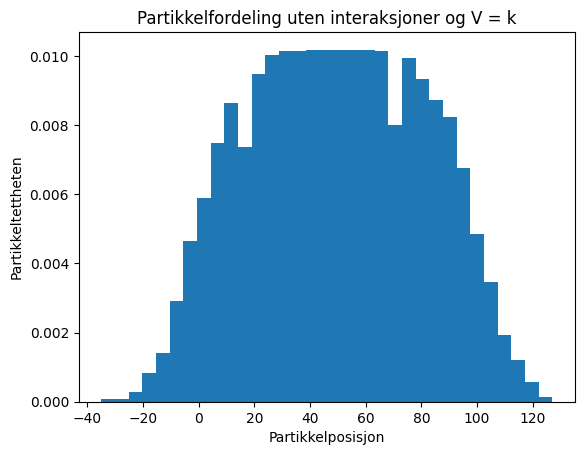

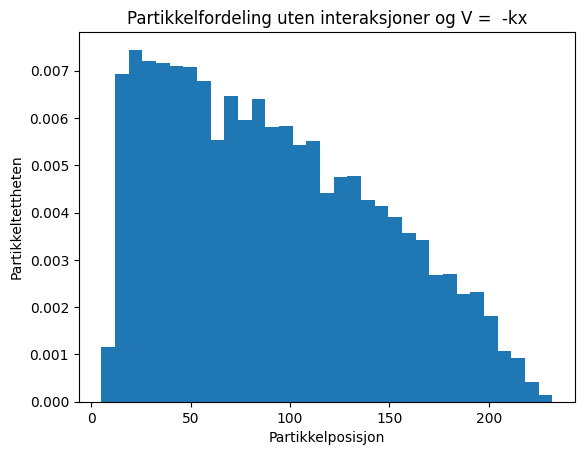

In [32]:
def oppg2_b():
    #Lager 2 instanser med virrevandring, en med hvert potensial.
    #Lar så begge gå med interaksjon
    n_steps = 100

    walker_V1 = random_walk(beta_k_ratio=1, V=V_1)
    walker_V2 = random_walk(beta_k_ratio=1, V=V_2)

    for j in tqdm(range(n_steps)):
        walker_V1.oppg_b_step()
        walker_V2.oppg_b_step()
        

    verdier1 = np.array(walker_V1.oppg_b_vals).flatten()
    plt.hist(verdier1, density=True, bins=walker_V1.n_particles//3)
    plt.xlabel(f'Partikkelposisjon')
    plt.ylabel(f'Partikkeltettheten')
    plt.title(f'Partikkelfordeling uten interaksjoner og V = k')
    plt.show()

    verdier2 = np.array(walker_V2.oppg_b_vals).flatten()
    plt.hist(verdier2, density=True, bins=walker_V2.n_particles//3)
    plt.xlabel(f'Partikkelposisjon')
    plt.ylabel(f'Partikkeltettheten')
    plt.title(f'Partikkelfordeling uten interaksjoner og V =  -kx')
    plt.show()

oppg2_b()

Ved konstant potensialet med interaksjoner vil det også bli en bred normalfordeling, men da de ikke kan overlappe, mister man mye av støyet. 100 partikler starter, i likhet med 2a), ved siden av hverandre fra 0 til 100. De rundt 50 på x-aksen vil ikke kunne bevege seg før de rundt også har beveget seg. De ytterste partikklene har altså størst sannsynlighet for å bevege seg, og har færre partikler rundt seg. Motsatt vil de partikklene i sentrum (50 på x-aksen) ha liten sannsynlighet for å bevege seg og mange partikler rundt seg. Den brede normalfordelingen gir altå mening.

Ved et negativt potensialet legger partikklene seg i en trekant-fordelinge med minst til høyre. Det er logisk, da alle partikklene sannsynligvis ønsker å dra til høyre, og de til høyre kan bevege seg fritt mot høyre, men av og vil noen partikler ikke bevege seg, og blokkere de bak seg fra å bevege seg til høyre. Sjansen for at et partikkel faktisk klarer å bevege seg til høyre minker altså desto flere partikler det har fremfor seg. 

### 2c)

  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\askin\AppData\Local\Temp\ipykernel_13048\3253290816.py:13: RuntimeWarning: overflow encountered in exp
  denonimator = 1 + np.exp(-beta*(V(x_0 + 1) - V(x_0 - 1))) + np.exp(-beta*(V(x_0) - V(x_0 - 1)))
100%|██████████| 100/100 [00:21<00:00,  4.67it/s]


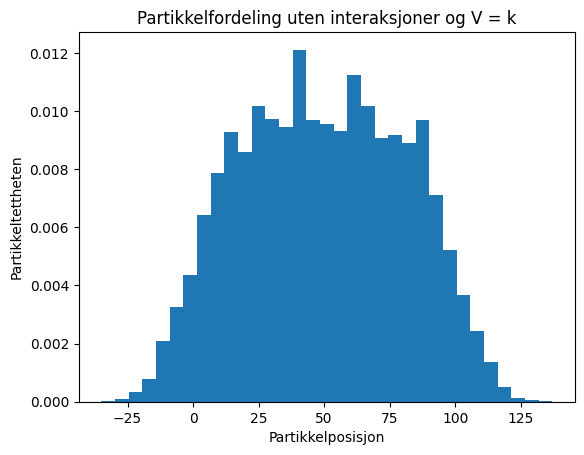

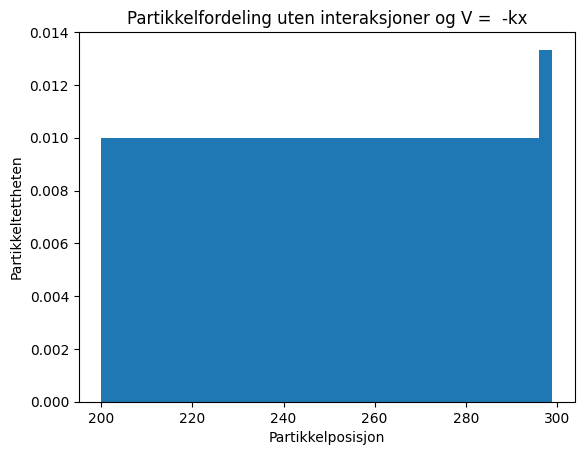

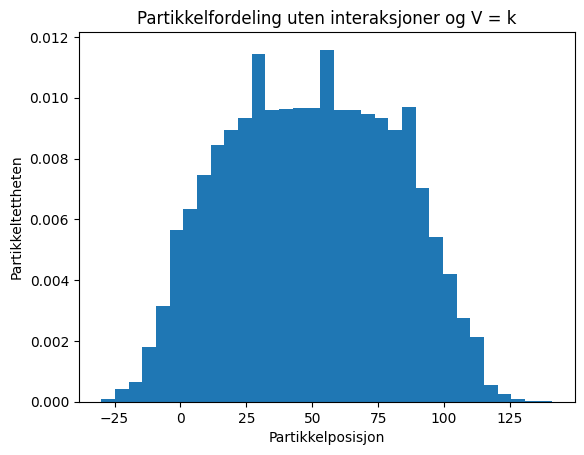

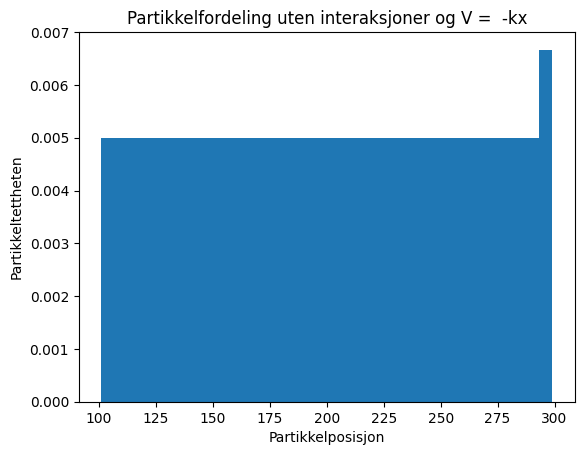

In [33]:
def oppg2_c():
    #Lager 2 instanser med virrevandring, en med hvert potensial.
    #Lar så begge gå med interaksjon
    n_steps = 100

    walker_V1 = random_walk(beta_k_ratio=1000, V=V_1)
    walker_V2 = random_walk(beta_k_ratio=1000, V=V_2)

    for j in tqdm(range(n_steps)):
        walker_V1.oppg_a_step()
        walker_V2.oppg_a_step()
        walker_V1.oppg_b_step()
        walker_V2.oppg_b_step()
        
    verdier1 = np.array(walker_V1.oppg_a_vals).flatten()
    plt.hist(verdier1, density=True, bins=walker_V1.n_particles//3)
    plt.xlabel(f'Partikkelposisjon')
    plt.ylabel(f'Partikkeltettheten')
    plt.title(f'Partikkelfordeling uten interaksjoner og V = k')
    plt.show()

    verdier2 = np.array(walker_V2.oppg_a_vals).flatten()
    plt.hist(verdier2, density=True, bins=walker_V2.n_particles//3)
    plt.xlabel(f'Partikkelposisjon')
    plt.ylabel(f'Partikkeltettheten')
    plt.title(f'Partikkelfordeling uten interaksjoner og V =  -kx')
    plt.show()

    verdier1 = np.array(walker_V1.oppg_b_vals).flatten()
    plt.hist(verdier1, density=True, bins=walker_V1.n_particles//3)
    plt.xlabel(f'Partikkelposisjon')
    plt.ylabel(f'Partikkeltettheten')
    plt.title(f'Partikkelfordeling uten interaksjoner og V = k')
    plt.show()

    verdier2 = np.array(walker_V2.oppg_b_vals).flatten()
    plt.hist(verdier2, density=True, bins=walker_V2.n_particles//3)
    plt.xlabel(f'Partikkelposisjon')
    plt.ylabel(f'Partikkeltettheten')
    plt.title(f'Partikkelfordeling uten interaksjoner og V =  -kx')
    plt.show()

oppg2_c()

Når $\beta k = 1000 $ vil potensialet de befinner seg i ha mye mer å si for hvor de går enn tilfeldigheten, se oppgave 1c. Når potensialet er konstant vil det altså være minimal forskjell på resultatet sammenliknet med med 1a). Når potensialet derimot blir negativt vil hver partikkel bevege seg i retning av minst potensiale nærmest hver gang. De beholder dermed uniformfordelingen de har fra starten, og beveger seg samlet mot minst potensial. Dette stemmer overens med simuleringene.

## Oppgave 3


##### Generelle funksjoner for å kjøre senere kode:

In [5]:
"""Antatte startparametre"""
#modifiseres i oppgavene der relevant
alpha = 0.8
T = 273.15 + 37
beta = (sp.constants.Boltzmann *T)**-1
N_x = 100
periods = 2
N_points = periods*N_x
N_particles = 12*N_x
k = 1000/beta

T_p = 500
h = 1

"""Sannsynlighetsutrykk"""
def p_plus(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 - 1) - V(x_0 + 1))) + np.exp(-beta*(V(x_0) - V(x_0 + 1)))
    return 1/denonimator

def p_zero(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 - 1) - V(x_0))) + np.exp(-beta*(V(x_0 + 1) - V(x_0)))
    return 1/denonimator

def p_minus(x_0, beta, V):
    denonimator = 1 + np.exp(-beta*(V(x_0 + 1) - V(x_0 - 1))) + np.exp(-beta*(V(x_0) - V(x_0 - 1)))
    return 1/denonimator

"""Potensialfunksjoner"""
def V_1_vectorized(x):
    #normaliserer x til periodisiteten
    V_1 = np.zeros(np.shape(x))

    L = -(1-alpha)*N_x
    positions = L + (x-L)%N_x

    #returnerer potensialet i punkt
    V_1 += (positions > 0) * positions*k / (alpha*N_x)
    V_1 += -1*(positions <= 0)*positions*k/ ((1-alpha)*N_x)
    
    return V_1
    

def V_2(x):
    return k


"""Simuleringsfunkjoner"""

def random_walk_system_vectorized(particles, positions, potential):
    """
        Funksjon som tar alle partiklene fram ett tissteg
        returnerer nye posisjoner og snittet strøm for tidssteget
    """

    movements = np.random.uniform(size=N_particles)
    particle_probs = np.array((p_minus(positions[particles], beta, potential), p_plus(positions[particles], beta, potential)))

    move_left = np.less_equal(movements, particle_probs[0])*1
    move_right = np.greater_equal(movements, 1 - particle_probs[1])*1
    n_plus = np.sum(move_right)
    n_minus = np.sum(move_left)

    particles += move_right - move_left

    
    particles -= np.equal(particles, N_points)*N_points
    particles += np.equal(particles, -1)*N_points

    particles = np.where(particles == 200, 0, particles)
    particles = np.where(particles == -1, periods * N_x - 1, particles)

    return particles, (n_plus-n_minus) / N_particles
    


def random_walk_cycle_vectorized(positions,particles):
    """
        Funkjon som tar hele systemt en syklus (2 T_p tidssteg)

        returnerer posisjonene etter syklusen og snittet strøm for syklusen
    """

    avg_stream = 0
    
    #går alle tidsstegene
    for timestep in range(2*T_p):
        
        #antar V1 med mindre vi er i en oddetalls del av syklusen
        V = V_2
        if timestep > T_p:
            V = V_1_vectorized

        
        #lagerer strømmene
        particles, stream = random_walk_system_vectorized(particles, positions, V)
        avg_stream += stream

    avg_stream /= 2*T_p

    return particles, avg_stream

"""Analytiske utrykk"""

def analytical_avg_current(a, Tp):
    """
        Analytisk strømning som funkjon av alpha og T_p
    """

    multiplier = N_x/2 * np.sqrt(3/Tp)
    erfc_left = sp.special.erfc(a*multiplier)
    erfc_right = sp.special.erfc((1-a)*multiplier)

    return N_x/(4*Tp) * (erfc_left - erfc_right)


#### Oppgaver:

#### 3a)

In [35]:
def oppgave_3_a(num_cycles = 10):

    """
        Initialiserer parameterene og printer for hver syklus for oppgave 3a
    """
    global N_x
    N_x = 100
    
    global N_particles
    N_particles = 12*N_x

    global alpha
    alpha = 0.8

    global T_p
    T_p = 500

    #Initialliserer partikellene jevnt utover 
    particles = np.array((np.arange(0, N_points, 1, dtype=np.int16),))
    one = np.ones((int(N_particles/N_points),1), dtype = np.int16)
    particles = np.ndarray.flatten(one @ particles)

    positions = np.linspace(0, h*N_points-1, N_points)
    streams = np.zeros(num_cycles)

    #Kjører systemet én syklus og printer snitt strømmen
    for cycle in range(num_cycles):
        particles, streams[cycle] = random_walk_cycle_vectorized(positions, particles)
        print(f"cycle: {cycle}, average stream {streams[cycle]}")

   
oppgave_3_a()

cycle: 0, average stream -0.02891666666666665
cycle: 1, average stream -0.014333333333333339
cycle: 2, average stream -0.01133333333333334
cycle: 3, average stream -0.013583333333333333
cycle: 4, average stream -0.01275
cycle: 5, average stream -0.01125
cycle: 6, average stream -0.012249999999999997
cycle: 7, average stream -0.013583333333333334
cycle: 8, average stream -0.013750000000000004
cycle: 9, average stream -0.012166666666666668



Netto strømning blir større enn null ettersom vi ikke har ren diffusjon. Når potensialet er konstant, er sannsynlighetene for bevegelse i positiv og negativ retning like. Dermed blir netto strømning null. Når sagtannpotensialet er aktivt derimot blir $p^+ {\not =} p^-$ for alle bindingspunkter (utenom tilfellet der $\alpha = 0.5$). Og partiklene der vil tendere mot en retning. Hvilken retning en partikkel på et gitt bindingspunkt tenderer mot vil avhenge av $\alpha$.

Bare i tilfellet der sagtann potensialet er symmetrisk om toppunktet ($\alpha = 0.5$) vil strømningen være 0 ettersom begge potensialene er symmetriske.

Vi ser en større strøm i den første syklusen enn vi gjør i de senere (ca dobbelt så stor). Dette kommer av at når denne syklusen starter er alle proteinene fordelt jevn over rommet. Under starten av senere sykler derimot vil proteinene alle være bundet i en brønn i sagtann potensialet. Når de diffunderer herfra kommer færre til å forflytte seg over neste potensialtopp før sagtannpotensialet blir gjeldene.

#### 3b)

100%|██████████| 50/50 [00:07<00:00,  6.27it/s]


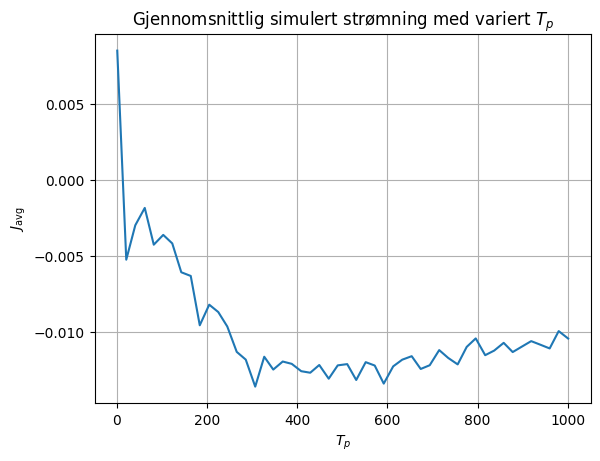

In [6]:
def oppgave_3_b(num_values = 50):
    """
        Initialiserer parameterene og plotter gjennomsnitlig strømning per syklus mot T_p
    """

    global N_particles
    N_particles = 4*N_x

    global alpha
    alpha = 0.8

    #initialliserer partiklene i bunnpunkt for sagtann poteniale
    particles_start = np.zeros(N_particles, dtype=np.int16)
    particles_start[::2] = h*N_x
    positions = np.linspace(0, h*N_points, N_points)
    streams = np.zeros(num_values)
    

    global T_p
    Tp_range = np.linspace(1, 1001, num_values, dtype=np.int16) 

    # itererer over tids steg lengdene flere ganger og tar gjennomsnitt for å få mindre støy i data
    for _ in range(5):
        for i,T in enumerate(tqdm(Tp_range)):
            T_p = T
            particles = np.copy(particles_start)
            _, s = random_walk_cycle_vectorized(positions, particles)
            streams[i] += s
    streams /= 5

    #plotter
    plt.plot(Tp_range, streams)
    plt.grid()
    plt.title(f"Gjennomsnittlig simulert strømning med variert $T_p$")
    plt.xlabel(f"$T_p$")
    plt.ylabel(r"$J_\text{avg}$")
    plt.show()

oppgave_3_b()

Strømningen øker mot venstre med økt $T_p$ i intervallet cirka $[1,500]$, etter dette minker strømningen sakte. Økningen i strømning mot venstre i det første intervallet skyldes nok at proteinene får mer tid til å diffundere, hvilket gjør at fler av dem kan stige over i neste konvekse del av potensialet. Nedgangen for $T_p > \sim 500$ skyldes nok dermed at vi når et punkt der proteinene er nært uniformt fordelt. Dermed vil påfølgende tissteg ikke bidra til å øke strømningen ved potensialbytte. Proteinene vil også bruke mer tid "fanget" i potenisalbrønnene. Dermed øker ikke netto strømning. Og ettersom $J_\text{avg} \propto \frac 1 T_p $ bidrar dette til at $J_\text{avg}$ synker.

#### 3c)

  0%|          | 0/50 [00:00<?, ?it/s]C:\Users\askin\AppData\Local\Temp\ipykernel_13048\1279418025.py:17: RuntimeWarning: overflow encountered in exp
  denonimator = 1 + np.exp(-beta*(V(x_0 - 1) - V(x_0 + 1))) + np.exp(-beta*(V(x_0) - V(x_0 + 1)))
 96%|█████████▌| 48/50 [00:12<00:00,  3.83it/s]C:\Users\askin\AppData\Local\Temp\ipykernel_13048\1279418025.py:25: RuntimeWarning: overflow encountered in exp
  denonimator = 1 + np.exp(-beta*(V(x_0 + 1) - V(x_0 - 1))) + np.exp(-beta*(V(x_0) - V(x_0 - 1)))
100%|██████████| 50/50 [00:13<00:00,  3.78it/s]


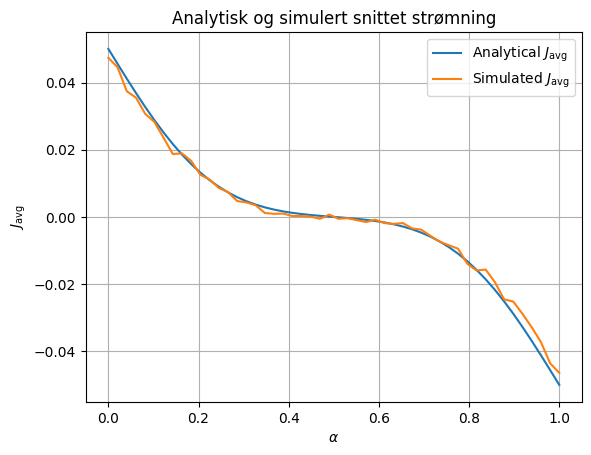

In [37]:

def oppgave_3_c(num_values = 50):
    """
        Initialiserer parameterene, Plotter gjennomsnitslig strømning per syklus mot alpha og det analytiske utrykket for gjennomsnitslig strømning sfa alpha
    """

    global T_p
    T_p = 500
    global N_particles
    N_particles = 12*N_x
    
    #initialiserer i potenial brønner
    particles_start = np.zeros(N_particles, dtype=np.int16)
    particles_start[::2] = h*N_x

    
    positions = np.linspace(0, h*N_points, N_points)
    streams = np.zeros(num_values)
    i = 0

    global alpha
    alpha_range = np.linspace(1e-5,1-1e-5,num_values) #Velger små verdier som approximerer de egentlige grensene for å unngå overflow 

    # itererer over alpha verider
    for a in tqdm(alpha_range):
        alpha = a
        particles = np.copy(particles_start)
        _, streams[i] = random_walk_cycle_vectorized(positions, particles)
        i+=1

    #plotter
    plt.plot(alpha_range, analytical_avg_current(alpha_range, T_p,), label=r"Analytical $J_\text{avg}$")
    plt.plot(alpha_range, streams, label=r"Simulated $J_\text{avg}$")
    plt.legend()
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_\text{avg}$")
    plt.title("Analytisk og simulert snittet strømning")
    plt.grid()
    plt.show()
    
oppgave_3_c()

Den simulerte strømningen passer godt med den analytiske. Vi ser at for små $\alpha$ er $J_\text{avg} > 0$, altså går netto strømning mot høyre. For store $\alpha$ går strømmen mot venstre. Som nevnt i a) er strømningen 0 for $\alpha \approx 0.5$.  Når $\alpha$ er liten er majoriteten av hver "sagtann" til høyre for toppen hvilket gir økt sannsynlighet for steg til høyre. Samme logikk forklarer strømning i negativ retning for $\alpha > 0.5$. Dermed passer den analytiske løsningen det vi forventer gitt sannsynlighets funksjonene.

#### 3d)

100%|██████████| 6/6 [01:17<00:00, 12.85s/it]


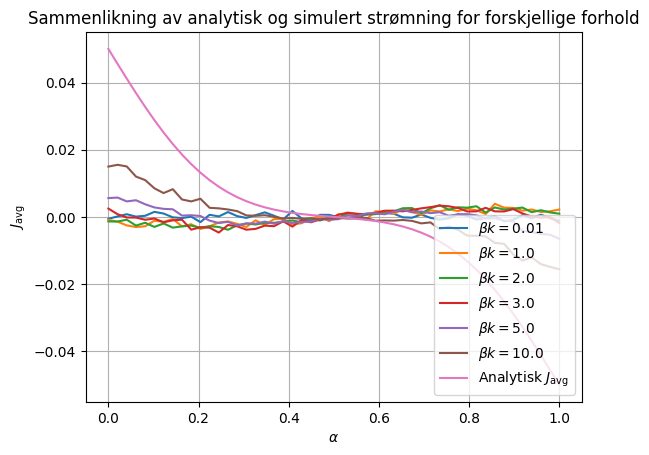

In [38]:
def oppgave_3_d(num_values = 50):
    """
        Initialiserer parameterene, Plotter gjennomsnittlig strømning per syklus mot alpha for gitte verdier av k*beta og det analytiske utrykket for gjennomsnittlig strømning sfa alpha
    """


    global T_p
    T_p = 500
    global N_particles
    N_particles = 12*N_x
    
    #initialiserer i potensialbrønner
    particles_start = np.zeros(N_particles, dtype=np.int16)
    particles_start[::2] = h*N_x
    positions = np.linspace(0, h*N_points, N_points)
    streams = np.zeros(num_values)
    

    global alpha
    alpha_range = np.linspace(1e-5,1-1e-5,num_values) #Velger små verdier som approksimerer de egentlige grensene for å unngå overflow 

    global k
    kbeta = np.array((0.01,1,2,3,5,10))
    k_range = kbeta/beta

    #itererer over k verider og alphaer
    for j,e in enumerate(tqdm(k_range)):
        k = e
        for i,a in enumerate(alpha_range):
            alpha = a
            particles = np.copy(particles_start)
            _, streams[i] = random_walk_cycle_vectorized(positions, particles)

        plt.plot(alpha_range, streams, label=r"$\beta k = $" + str(kbeta[j]))


    plt.plot(alpha_range, analytical_avg_current(alpha_range, T_p), label=r"Analytisk $J_\text{avg}$")
    plt.xlabel(r"$\alpha$")
    plt.ylabel(r"$J_\text{avg}$")
    plt.title("Sammenlikning av analytisk og simulert strømning for forskjellige forhold")
    plt.legend()
    plt.grid()
    plt.show()

oppgave_3_d()

Vi ser at for lave verdier av $\beta k $ er det dårlig samsvar mellom den simulerte og den analytiske verdien av $J_\text{avg}$. Men verdiene passer bedre for større $\beta k$. Ettersom det i oppgave c) med $\beta k = 1000$ var tilnærmet perfekt samsvar mellom simulert og analytisk strømning tyder dette på at den analytiske løsningen eksisterer i grensen der den kjemiske energien i systemet er langt større enn den termiske energien. Altså $\beta k \gg 1$. 

#### 3e)

  0%|          | 0/20 [00:00<?, ?it/s]C:\Users\askin\AppData\Local\Temp\ipykernel_14132\1279418025.py:25: RuntimeWarning: overflow encountered in exp
  denonimator = 1 + np.exp(-beta*(V(x_0 + 1) - V(x_0 - 1))) + np.exp(-beta*(V(x_0) - V(x_0 - 1)))
100%|██████████| 20/20 [00:04<00:00,  4.21it/s]


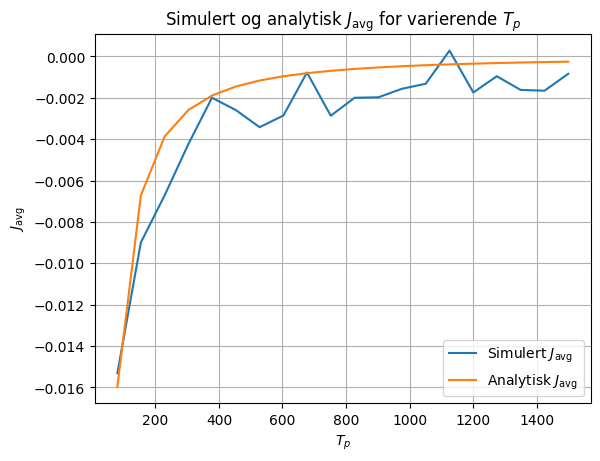

In [8]:

def oppgave_3_e(num_values = 20):
    """
        Initialiserer parameterene, Plotter gjennomsnittlig strømning per syklus mot T_p og det analytiske utrykket for gjennomsnittlig strømning sfa T_p
    """
    global N_x
    N_x = 10

    global periods
    periods = 20

    global N_points
    N_points = periods*N_x

    global N_particles
    N_particles = 40*N_x

    global alpha
    alpha = 0.8

    #initialiserer i potensialbrønner
    particles_start = np.zeros(N_particles, dtype=np.int16)
    particles_start[::2] = h*N_x

    positions = np.linspace(0, h*N_points, N_points)
    streams = np.zeros(num_values)

    global T_p
    Tp_range = np.linspace(80, 1500, num_values, dtype=np.int16)

    #itererer over tidssteg lengder
    for i, T in enumerate(tqdm(Tp_range)):
        T_p = T
        particles = np.copy(particles_start)
        _, streams[i] = random_walk_cycle_vectorized(positions, particles)


    #plotter
    plt.plot(Tp_range, streams, label=r"Simulert $J_\text{avg}$") 
    plt.plot(Tp_range, analytical_avg_current(alpha, Tp_range), label=r"Analytisk $J_\text{avg}$")
    plt.xlabel('$T_p$')
    plt.ylabel('$J_\\text{avg}$')
    plt.title('Simulert og analytisk $J_\\text{avg}$ for varierende $T_p$')
    plt.legend()
    plt.grid()

    plt.show()

oppgave_3_e()

Sammenhengen mellom simulert og analytisk data plottet mot $T_p$ er relativt god. For de minste verdiene av $T_p$ ($ < \sim 100$)  er den simulerte og analytiske strømmen nærmest identisk. Utenfor dette intervallet er den simulerte strømmen større enn den analytiske. Det ser ut til å konvergere for større perioder for potensiale. Dette kan komme av at større perioder fører til at simulerigen får mer tid det partiklene står stille og dermed at strømningen synker. I tillegg er både analytisk og simulert strømning inversproposjonale med $T_p$. Hvilket gjør for at strømningen minker for større $T_p$.

#### 3f)
Det er tydelig at den analytiske løsningen bygger på et sett med antagelser. Som nevnt i d) er det liten grad av likhet mellom modellene når den termiske energien dominerer systemet. Dermed kan en anta at den analytiske løsningen bygger på en antagelse om at systemet eksisterer i grensen $k_b T \ll K$.

Videre antar den analytiske løsningen kontinuitet, noe vi ser fra formlen hvor det integreres over kontinuerlige sannsynlighetsfordelinger. Differansen som oppstår av dette er liten og slår dessuten begge veier. Variasjonen kan minkes ved å kjøre simulasjonen med flere partikler. 

Det er også verdt og merke seg at utrykket for $J_\text{avg}$ er forskjellig for simulert og analytisk modell. Den analytiske modellen regner et skritt til høyre som én potenisalbrønn til høyre, mens simuleringen regner høyre skritt til å være et bindingspunkt til høyre.
Ettersom den slakere delen av potensialet er lengre enn den bratte vil simulerte proteiner ta flere steg mot bunnen av brønnen dersom de ender opp på den slake siden enn om de hadde endt opp på den bratte. Dermed blir det målte tallet for strømmen i det simulerte tilfellet større. For at disse skal bli likere kan man vekte leddene som gir positiv og negativ strømning for antall steg vi forventer at en partikkel vil ta i den retningen.

## Oppgave 4


### Generell kode som brukes i oppgavene:

In [2]:
@njit
def p_plus(beta, V_xm1, V_xp1, V_x0):
    denonimator = 1 + np.exp(-beta*(V_xm1 - V_xp1)) + np.exp(-beta*(V_x0 - V_xp1))
    return 1/denonimator

@njit
def p_zero(beta, V_xm1, V_xp1, V_x0):
    denonimator = 1 + np.exp(-beta*(V_xm1 - V_x0)) + np.exp(-beta*(V_xp1 - V_x0))
    return 1/denonimator

@njit
def p_minus(beta, V_xm1, V_xp1, V_x0):
    denonimator = 1 + np.exp(-beta*(V_xp1 - V_xm1)) + np.exp(-beta*(V_x0 - V_xm1))
    return 1/denonimator

@njit
def V_1(x : np.array):
    "Sagtannspotensiale"
    
    #Mapper x til periodisiteten
    L = -(1 - alpha) * N_x
    x = L + (x - L) % N_x

    #delt funksjonsuttrykk
    x_less = (0 <= x) & (x <= alpha*N_x)
    x_more = (-(1-alpha)*N_x < x) & (x <= 0)
    x[x_less] = k * x[x_less]/ (alpha*N_x)
    x[x_more] = -k*x[x_more]/((1-alpha)*N_x)
    
    return x

@njit
def V_2(x):
    "Konstant potensiale"
    return np.full_like(x, k, dtype=np.float64)

@njit
def gen_walk_masks(N_particles, beta, V_xm1, V_xp1, V_x0):
    '''Regner ut p minus samt p pluss og bruker uniform distribusjon til
    å bestemme om hver partikkel skal gå venstre, høyre eller ikke bevege seg'''
    uniform_dist = np.random.uniform(0, 1, N_particles)
    go_left = uniform_dist <= (p_minus(beta, V_xm1, V_xp1, V_x0))
    go_right = uniform_dist >= 1-(p_plus(beta, V_xm1, V_xp1, V_x0))
    return go_left, go_right

@njit
def random_walk_ratchet_potential(particles, N_timesteps, T_p, N_particles, N_points, b, beta):
    "Simulerer virrevandring i aksjonspotensiale med frastøtning"
    np.random.seed(120) #Seeder random for å sikre reproduserbare resultater

    #Array for partikkelstrømmer for en syklus slik at snittet kan utregnes
    particle_current_buffer = np.zeros(2*T_p)


    #Definerer under ulike arrays som kan holde på plotteverdier til senere

    #Velger tilfeldige partikler som plottes
    plt_particle_idxs = np.random.choice(np.arange(0, N_particles), size = min(5, N_particles), replace=False)
    particle_movements = np.zeros((N_timesteps, min(5, N_particles)))


    cycle_averaged_particle_currents = np.zeros(N_timesteps // 2*T_p)
    vline_plot_points = vline_plot_points = np.zeros((N_timesteps // T_p, 2), dtype=np.int64) # Brukes i plotting senere for å indikere potensialbytte
    potential_switch_count = 0



    for j in range(N_timesteps):
        n_plus = 0
        n_minus = 0

        #Itererer periodisk gjennom potensialer etter T_p tidssteg
        if (j % T_p == 0) & (j != 0):
            potential_switch_count += 1
            curr_potential = potential_switch_count % 2
            vline_plot_points[j//T_p] = np.array([j, curr_potential])


        x0 = particles
        if curr_potential == 0:
            V_xm1, V_xp1, V_x0 = V_1(x0 -1), V_1(x0 + 1), V_1(x0)
        else:
            V_xm1, V_xp1, V_x0 = V_2(x0 -1), V_2(x0 + 1), V_2(x0)
        go_left, go_right = gen_walk_masks(N_particles, beta, V_xm1, V_xp1, V_x0)

        #Velger tilfeldig rekkefølge på partikkelbevegelse
        movement_order = np.random.permutation(np.arange(N_particles))
        for curr_particle_idx in movement_order:
            distance_from_particle = np.copy(particles) - particles[curr_particle_idx]
            if go_left[curr_particle_idx]:
                if np.any((distance_from_particle > -b) & (distance_from_particle < 0)):
                    continue
                else:
                    #Denne if-statementen sjekker om periodisk randbetingelse er brutt
                    if curr_particle_idx <= b:
                        boundary = N_points - 1 - (b - curr_particle_idx) # -1 pga 0-indeksering
                        if np.any(distance_from_particle >= boundary):
                            continue
                
                #Denne koden kjører kun dersom ingen if-statements ovenfor er gyldig
                particles[curr_particle_idx] -= 1
                n_minus += 1

            elif go_right[curr_particle_idx]:
                if np.any((distance_from_particle < b) & (distance_from_particle > 0)):
                    continue
                if curr_particle_idx >= N_points - 1 - b:
                    boundary = b - (N_points - 1 - curr_particle_idx)
                    if np.any(np.abs(distance_from_particle) >= N_points - 1 - boundary):
                        continue

                particles[curr_particle_idx] += 1
                n_plus += 1

            #Syklisk randbetingelser for x
            if particles[curr_particle_idx] >= N_points:
                particles[curr_particle_idx] = 0
            
            elif particles[curr_particle_idx] <= -1:
                particles[curr_particle_idx] = N_points - 1
        
        
        normalized_particle_current = (n_plus - n_minus) / N_particles
        particle_current_buffer[j % len(particle_current_buffer)] = normalized_particle_current
        particle_movements[j] = (particles[plt_particle_idxs])

        #Etter hver syklus regnes snittet partikkelstrøm ut og lagres
        if (j % (2*T_p) == 0) & (j != 0):
            cycle_averaged_particle_currents[N_timesteps // (2*j)] = np.average(particle_current_buffer)

    return potential_switch_count, cycle_averaged_particle_currents, particle_movements, vline_plot_points



class ratchet_interaction_walker():
    "Klasse for å simulere oppgave 4. Hovedsakelig laget for lettere implementering av kode"
    def __init__(self, cfg : dict):
        self.cfg = cfg
        k_b = sp.constants.Boltzmann
        self.potentials = [V_1, V_2]
        self.T = cfg['T']
        self.beta = (self.T * k_b)**-1
        self.beta_k_ratio = cfg['beta_k_ratio']
        self.k = self.beta_k_ratio * (self.T * k_b)
        self.b = cfg['b']
        self.T_p = cfg['T_p']
        self.N_cycles = cfg['N_cycles']
        self.alpha = cfg['alpha']
        self.N_x = cfg['N_x']
        self.N_points = self.N_x * cfg['N_s']
        self.N_particles = cfg['N_p']
        self.N_timesteps = self.T_p * 2 * self.N_cycles


        #Må gjøre noen av variablene globale for at potensial-funksjonene skal kunne brukes
        global k
        global alpha
        global N_x
        k = self.k
        alpha = self.alpha
        N_x = self.N_x
  
    def plot_sawtooth_potential(self):
            "Visualiserer potensiallandskapet i sagtannsfasen"
            x = np.linspace(0,1000, num=10000)
            V_vals = V_1(x)
            plt.plot(x, V_vals)
            plt.show()

    def interaction_simulator(self):
        '''Simulerer "Random walk in a ratchet potential with interactions". Returnerer alle tidssteg samt alle x-posisjoner til tilfeldig utvalgte partikler'''

        if self.N_particles == 1:
            particles = np.array([self.N_points // 2])
        else:
            particles = np.linspace(0, self.N_points -1, self.N_particles, dtype=np.int64)

        self.potential_switch_count, self.cycle_averaged_particle_currents, particle_movements, self.vline_plot_points = random_walk_ratchet_potential(
            particles,
            self.N_timesteps,
            self.T_p,
            self.N_particles,
            self.N_points,
            self.b,
            self.beta
        )

        particle_movements = np.array(particle_movements).T
        #Tar gjennomsnittet av alle syklus-snittede partikkelstrømningene for å få ett enkelt tall
        self.cycle_averaged_particle_currents = np.average(self.cycle_averaged_particle_currents)


        return (np.arange(self.N_timesteps), particle_movements)
    


def plot_particle_movement(walker : ratchet_interaction_walker, cfg : dict, x_array : np.array, T : np.array, plot_potential_switches = True):
    "PLotter posisjonen til et forhåndsvalgt antall partikler gjennom simuleringen"
    plt.figure(2)
    for x in x_array:

        #Fjerner diskontinuiteter fra plottet [KI generert]
        x_float = x.astype(np.float64)
        diffs = np.abs(np.diff(x_float)) 
        jump_indices = np.where(diffs >= (cfg['N_x']*cfg['N_s'] - 10))[0]
        for idx in jump_indices:
            if idx + 1 < len(x_float):
                x_float[idx + 1] = np.nan



        plt.plot(T, x_float)
    
    #Plotter vertikale linjer som viser potensialbytte om ønskelig
    if plot_potential_switches:
        for t, potential_idx in walker.vline_plot_points:
            if potential_idx % 2 == 0:
                color = 'green'
                label = '$V_1$' if t == walker.vline_plot_points[0][0] else ''
            else:
                color = 'black'
                label = '$V_2$' if t == walker.vline_plot_points[1][0] else ''
            plt.axvline(t, color=color, linestyle='--', label = label)
    else:
        plt.grid()
    plt.legend()
    plt.title('Partikkelbevegelse over tid i aksjonspotensiale med frastøtning')
    plt.xlabel('Tidssteg')
    plt.ylabel('Plassering')
    plt.show()

def rho_iterator(cfg: dict, T_p = 'default'):
    '''Finner alle syklus-snittede partikkelstrømninger for oppgitt intervall av rho. 
    Returnerer:         \n
    -Walker-objektet    \n
    -Liste med tuppler av (rho-verdien, liste over alle cycle-averaged particle currents for rho-verdien)    \n
    -Liste med utvalg av partikkelbevegelser for gitt rho
    '''

    rho_current_values = list()
    x_t_values = list()

    #Endrer T_p dersom ønskelig, men holder T_p * N_c = 30 000
    if not isinstance(T_p, str):
        cfg['T_p'] = int(T_p)
        cfg['N_cycles'] = int(3E4 / T_p)

    #Finner antall partikler som tilsvarer oppgitt intervall for partikkeltettheter i oppgaven
    N_p_min, N_p_max = np.ceil(np.array([cfg['rho_min'],cfg['rho_max']]) * cfg['N_s'] * cfg['N_x'] / cfg['b']).astype(int)
    for N_p in tqdm(np.arange(N_p_min, N_p_max + 1)):
        cfg['N_p'] = N_p
        rho = N_p * cfg['b'] / (cfg['N_x'] * cfg['N_s'])
        walker = ratchet_interaction_walker(cfg)
        T, x_array = walker.interaction_simulator()
        x_t_values.append([T, x_array])
        rho_current_values.append([rho, walker.cycle_averaged_particle_currents])
        

    rho_current_values = np.array(rho_current_values).T
    return walker, rho_current_values, x_t_values
  


#### 4a)

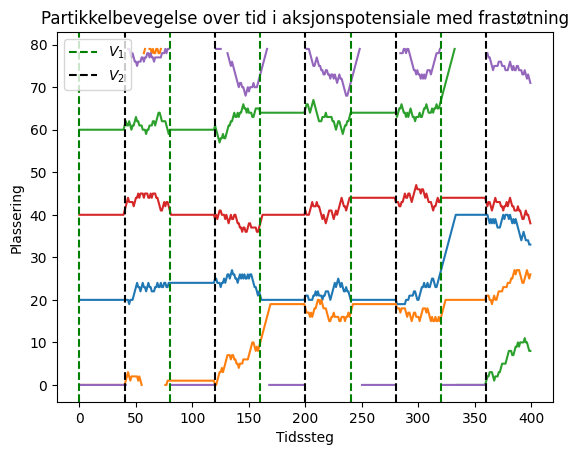

In [9]:
def oppg4a(cfg : dict):
    walker = ratchet_interaction_walker(cfg)
    T, x_array = walker.interaction_simulator()

    plot_particle_movement(walker, cfg, x_array, T, '4a')

cfg = {"alpha": 0.2,
  "T": 310.15,
  "N_x": 20,
  "T_p": 40,
  "N_cycles": 5,
  "N_s": 4,
  "beta_k_ratio": 1000,
  "N_p": 5,
  "b": 2}
  
oppg4a(cfg)

Som plottet viser har alle partiklene to ulike typer bevegelse i potensiallandskapet. Ved konstant potensiale $V(x) = k$ er alle sannsynlighetene for bevegelse like, så partiklene diffunderer. Ved bytte til sagtannspotensialet beveger deretter alle partiklene seg i retning av nærmeste potensialbrønn og forblir der. Forskjellen mellom oppførselen her og i oppgave 3 er naturligvis at ettersom vi modellerer avstøtning mellom partiklene kan de ikke oppta samme punkt. Dermed vil kun en partikkel kunne nå bunnen av en gitt potensialbrønn, og alle andre partikler som faller mot samme brønn vil forbli liggende "oppå" denne partikkelen i potensialfeltet. I denne modellen vil dette bety at hver påfølgende partikkel som legges til i en potensialbrønn allerede inntatt av en annen partikkel vil ha høyere sannsynlighet for å bevege seg videre i potensialet til en annen brønn, og dermed skape partikkelstrømning selv i sagtannspotensialet. Dette er jo da gitt at sagtannspotensialet er usymmetrisk, altså $\alpha\neq0.5$.

#### 4b)

100%|██████████| 50/50 [00:28<00:00,  1.74it/s]


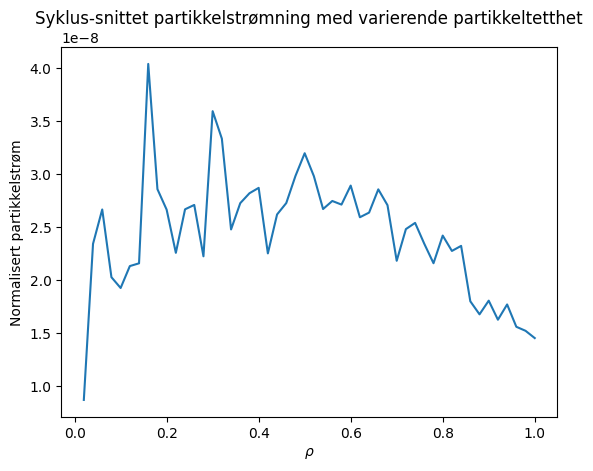

In [3]:
def oppg4b(cfg : dict):
    plot_values = rho_iterator(cfg, '4b')
    walker, rho_current_values, x_t_values = plot_values
    rho, avg_current = rho_current_values

    plt.plot(rho, avg_current)
    plt.title('Syklus-snittet partikkelstrømning med varierende partikkeltetthet')
    plt.xlabel('$\\rho$')
    plt.ylabel('Normalisert partikkelstrøm')
    plt.show()

cfg = {
  "alpha": 0.2,
  "T": 310.15,
  "N_x": 100,
  "T_p": 300,
  "N_cycles": 100,
  "N_s": 10,
  "beta_k_ratio": 1000,
  "N_p": 100,
  "b": 20, # Partikkelstørrelse
  "rho_min": 0.01,
  "rho_max": 1}

oppg4b(cfg)

Økende partikkeltetthet holder partikkelstrømningen relativt stabil inntil omtrent $\rho = 0.8$, og deretter synker strømningen. 

#### 4c)

---------------- T_P = 100 ----------------


100%|██████████| 50/50 [00:20<00:00,  2.42it/s]


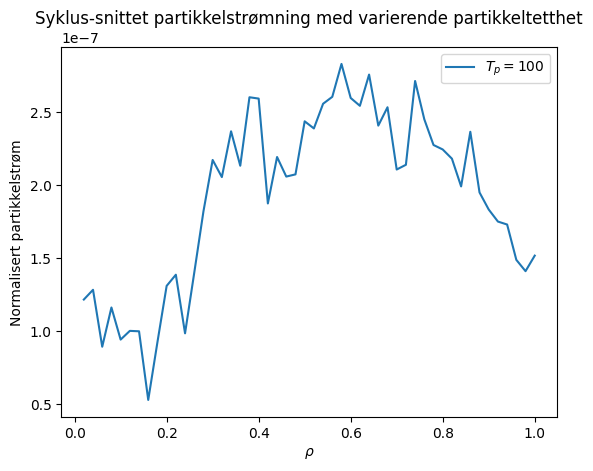

---------------- T_P = 300 ----------------


100%|██████████| 50/50 [00:21<00:00,  2.31it/s]


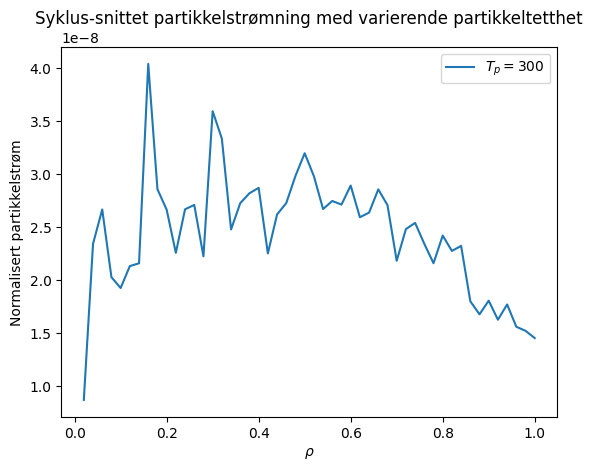

---------------- T_P = 600 ----------------


100%|██████████| 50/50 [00:23<00:00,  2.17it/s]


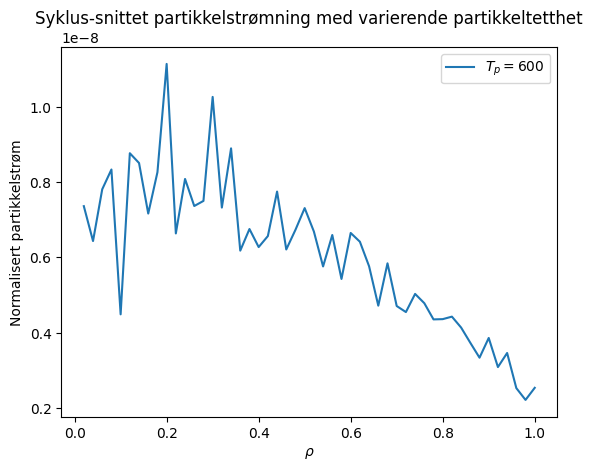

---------------- T_P = 1000 ----------------


100%|██████████| 50/50 [00:24<00:00,  2.06it/s]


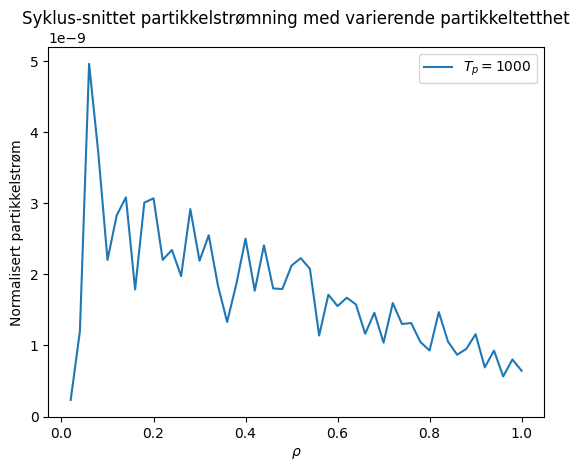

<Figure size 640x480 with 0 Axes>

In [4]:
cfg = {
  "alpha": 0.2,
  "T": 310.15,
  "N_x": 100,
  "T_p": 300,
  "N_cycles": 100,
  "N_s": 10,
  "beta_k_ratio": 1000,
  "N_p": 100,
  "b": 20, # Partikkelstørrelse
  "rho_min": 0.01,
  "rho_max": 1}


def oppg4c(cfg : dict):
    T_p_vals = np.array([100, 300, 600, 1000])
    for T_p in T_p_vals:
        print(f'---------------- T_P = {T_p} ----------------')
        plot_vals = rho_iterator(cfg, T_p)
        walker, rho_current_values, x_t_values = plot_vals
        rho, avg_current = rho_current_values

        plt.plot(rho, (avg_current), label=f'$T_p = {T_p}$')
        plt.title('Syklus-snittet partikkelstrømning med varierende partikkeltetthet')
        plt.xlabel('$\\rho$')
        plt.ylabel('Normalisert partikkelstrøm')
        plt.legend()
        plt.show()
        plt.clf()

oppg4c(cfg)

Plottene ovenfor viser at strømningsfunksjonens maksimum skjer for mindre og mindre partikkeltetthet med voksende antall tidssteg. Det er hovedsakelig to ulike fenomener som forklarer denne oppførselen. For lave nok $T_p$ vil ikke partiklene rekke å diffundere fullstendig mellom byttene av potensiale. Dette betyr at for lave tettheter vil alle partiklene være bundet til potensialbrønnene, og de får kun byttet dersom de under diffunderingsfasen tilfeldigvis beveger seg svært rettet mot en annen brønn. Med økende tetthet vil etterhvert flere partikler ligge i samme brønn. På grunn av det usymmetriske potensialet vil frastøtningen føre til at partiklene som er høyere opp i potensialfeltet posisjonsmessig ligger nærmere neste brønn, slik at de har høyere sannsynlighet for å bevege seg videre under konstant potensiale. Totalt er det dermed flere muligheter for en partikkel å bytte brønn, noe som fører til økt netto strømning. Når man derimot når en kritisk stor $\rho$ vil den positive effekten dette gir bli overskygget av blokkeringen som skjer ved for mange nabopartikler, og dermed minker netto strømning igjen.

Når $T_p$ blir tilstrekkelig stor vil partiklene så og si alltid ha tid til å diffundere til uniform fordeling uansett partikkeltetthet. Dette betyr at selv en enkelt partikkel vil kunne bytte brønn hver syklus. Dermed vil det å øke partikkeltettheten ikke ha noen positiv innvirkning i strømningen til hver enkelt partikkel. Den eneste mulige effekten er negativ, ved at to partikler møter hverandre og dermed potensielt hindrer hverandres bevegelse til neste brønn. Konsekvensen av dette for strømingene er at maksimum verdi skjer ved $N_p = 1$, og at alle påfølgende verdier vil være mindre eller lik denne strømmen. Dette er da fordi vi spesifikt undersøker normalisert partikkelstrøm.

Det er også verdt å merke at størrelsesordenen på partikkelstrømningen minker med økende $T_p$. Dette kommer av måten vi regner ut den syklus-snittede partikkelstrømmen på. Ved konstant potensiale har vi fra tidligere oppgaver forklart at netto strømning er rundt null. All strømningen i sagtannspotensialet skjer ved et omtrent konstant antall tidssteg ut ifra partikkeltettheten. Dette betyr at ettersom syklus-snittet strømning regnes ut ved å dele på antall tidssteg men selve strømningen skjer ved konstant tid blir resultatet at den gjennomsnittlige strømningen blir mindre.

#### 4d)
Ettersom det var utfordrende å finne en artikkel som oppfyllte alle spesifikasjonene optimalt, ble en artikkel valgt som ikke tar for seg "hard core repulsion", men heller Coulumb-krefter. Hver partikkel har derfor alle ladning lik -e, og det er bare disse kreftene som virker mellom partikklene. Artikkelen var fremdeles relevant for proskjektet vårt, og eksakt hvor ulikt det hadde vært med en hardkjærne-approksimasjon er uvisst. Partikklene vil nok spre seg gjevnere med Coulumb-krefter, men det er trolig mye likt.

Videre modellerer de et pulserende potensialet, slik som vi. Men de gjør dette i 2D og bruker et asymmetrisk potensial som er formet som en sinus-bølge og går gradvis fra negativt til positivt potensialet og tilbake. Partiklene som beveger seg måles fremdeles hvor langt de går i x-retning, men de har altså rom å bevege seg i y-retning. De fokuserer på å se på ulike partikkeltettheter og pulseringsfrekvenser.

Den finner at ved høyere partikkeltetthet kan man øke frekvensen til det pulserende potensialet, og man vil derfra få en større partikkelstrøm. Dette siden flere av partikklene kolliderer noe som fører til at mange av partikklene vil befinne seg nærmere neste intervall, og trenger kortere tid for å diffundere. De er på sett og vis allerede påbegynt diffusjonen. Dette ser man på figuren. De fargede tallene er antallet partikler i et gitt system. Ved ikke-interagerende partikler vil man derfor ikke få denne effekten og alle partiklene vil fortere sette seg "fast" i sitt intervall ved en høyere frekvens, da alle vil dra fra punktet med minst potensialet og rekker ikke over til neste intervall før frekvensen er tilbake til start.

Det andre de fant var at ved høy partikkeltetthet og lav frekvens får noen partikler så mye energi fra å kollidere at de hopper over flere intervaller. Dette skjedde ikke for høye frekvenser.

![alt text](image-2.png)

https://pubs.acs.org/doi/pdf/10.1021/acs.jpcc.9b00344?ref=article_openPDF
